#   BEHAVIORAL BIOMETRIC CONTINUOUS AUTHENTICATION

#   Method  : One-Class / Anomaly Detection (Unsupervised)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_curve

# Data Loading

In [2]:
df = pd.read_csv("DSL-StrongPasswordData.csv")

print(f"Dataset shape   : {df.shape}")
print(f"Subjects        : {df['subject'].nunique()}")
print(f"Sessions/subject: {df['subject'].value_counts().iloc[0]}")
print(f"Null values     : {df.isnull().sum().sum()}")
df.head()


Dataset shape   : (20400, 34)
Subjects        : 51
Sessions/subject: 400
Null values     : 0


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


# Feature Selection

In [3]:
# Drop metadata columns — keep only keystroke timing features
feature_cols = [c for c in df.columns if c not in ["subject", "sessionIndex", "rep"]]

print(f"Total timing features : {len(feature_cols)}")
print(f"Feature types         :")
print(f"  H.*   (Hold time)        : {sum(1 for c in feature_cols if c.startswith('H.'))}")
print(f"  DD.*  (Down-Down latency): {sum(1 for c in feature_cols if c.startswith('DD.'))}")
print(f"  UD.*  (Up-Down latency)  : {sum(1 for c in feature_cols if c.startswith('UD.'))}")

Total timing features : 31
Feature types         :
  H.*   (Hold time)        : 11
  DD.*  (Down-Down latency): 10
  UD.*  (Up-Down latency)  : 10


#  Feature Engineering

In [4]:
H_cols  = [c for c in feature_cols if c.startswith("H.")]
DD_cols = [c for c in feature_cols if c.startswith("DD.")]
UD_cols = [c for c in feature_cols if c.startswith("UD.")]

# Statistical features per keystroke type
df["mean_hold"]  = df[H_cols].mean(axis=1)
df["std_hold"]   = df[H_cols].std(axis=1)
df["min_hold"]   = df[H_cols].min(axis=1)
df["max_hold"]   = df[H_cols].max(axis=1)

df["mean_dd"]    = df[DD_cols].mean(axis=1)
df["std_dd"]     = df[DD_cols].std(axis=1)
df["min_dd"]     = df[DD_cols].min(axis=1)
df["max_dd"]     = df[DD_cols].max(axis=1)

df["mean_ud"]    = df[UD_cols].mean(axis=1)
df["std_ud"]     = df[UD_cols].std(axis=1)
df["min_ud"]     = df[UD_cols].min(axis=1)
df["max_ud"]     = df[UD_cols].max(axis=1)

# Ratio features — typing rhythm indicators
df["hold_dd_ratio"] = df["mean_hold"] / (df["mean_dd"] + 1e-9)
df["hold_ud_ratio"] = df["mean_hold"] / (df["mean_ud"] + 1e-9)
df["dd_ud_ratio"]   = df["mean_dd"]   / (df["mean_ud"] + 1e-9)

# Total typing time proxy
df["total_time"] = df[DD_cols].sum(axis=1)

# Update feature_cols to include new features
feature_cols = [c for c in df.columns if c not in ["subject", "sessionIndex", "rep"]]

print(f"Features after engineering : {len(feature_cols)}")
print(f"Added                      : {len(feature_cols) - 31} new features")

Features after engineering : 47
Added                      : 16 new features


# Exploratory Data Analysis

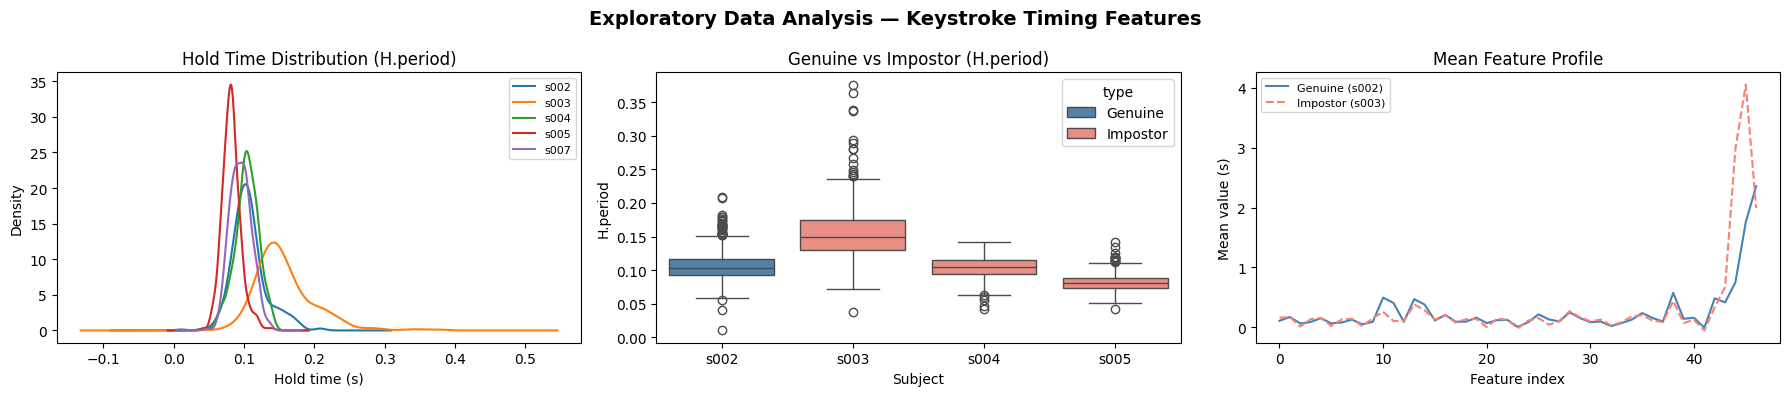

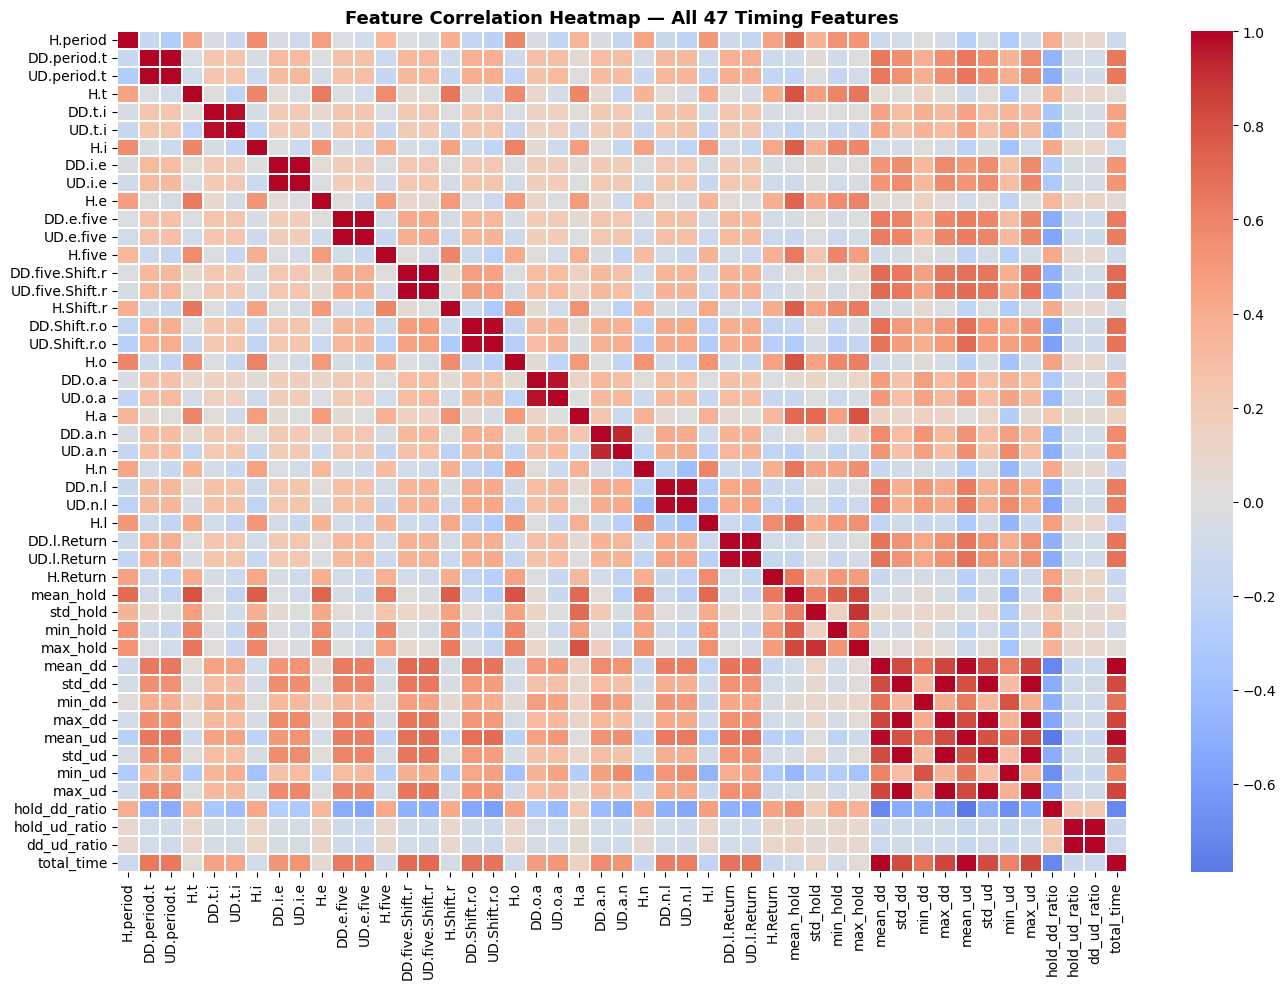

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Exploratory Data Analysis — Keystroke Timing Features", fontsize=14, fontweight="bold")

# Plot 1: KDE — Hold time distribution across 5 subjects
TARGET_USER = "s002"
for subj in df["subject"].unique()[:5]:
    df[df["subject"] == subj]["H.period"].plot(kind="kde", ax=axes[0], label=subj)
axes[0].set_title("Hold Time Distribution (H.period)")
axes[0].set_xlabel("Hold time (s)")
axes[0].legend(fontsize=8)

# Plot 2: Boxplot — genuine vs impostors
sample_subjects = [TARGET_USER, "s003", "s004", "s005"]
plot_df = df[df["subject"].isin(sample_subjects)][["subject", "H.period"]].copy()
plot_df["type"] = plot_df["subject"].apply(lambda x: "Genuine" if x == TARGET_USER else "Impostor")
sns.boxplot(data=plot_df, x="subject", y="H.period", hue="type",
            palette={"Genuine": "steelblue", "Impostor": "salmon"}, ax=axes[1])
axes[1].set_title("Genuine vs Impostor (H.period)")
axes[1].set_xlabel("Subject")

# Plot 3: Mean feature values — genuine vs one impostor
mean_genuine  = df[df["subject"] == TARGET_USER][feature_cols].mean()
mean_impostor = df[df["subject"] == "s003"][feature_cols].mean()
axes[2].plot(mean_genuine.values,  label="Genuine (s002)",  color="steelblue", linewidth=1.5)
axes[2].plot(mean_impostor.values, label="Impostor (s003)", color="salmon",    linewidth=1.5, linestyle="--")
axes[2].set_title("Mean Feature Profile")
axes[2].set_xlabel("Feature index")
axes[2].set_ylabel("Mean value (s)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 4: Correlation heatmap (separate — needs full size)
plt.figure(figsize=(14, 10))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0,
            linewidths=0.3, annot=False)
plt.title(f"Feature Correlation Heatmap — All {len(feature_cols)} Timing Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Each subject takes turn as genuine user
# All other 50 subjects = impostors (test only)

In [6]:
rng          = np.random.default_rng(42)
all_subjects = df["subject"].unique()
all_results  = []

print(f"Running authentication loop for {len(all_subjects)} subjects...\n")

for idx, TARGET_USER in enumerate(all_subjects, 1):

    # 1. Outlier Removal
    genuine_df     = df[df["subject"] == TARGET_USER][feature_cols].copy()
    Q1             = genuine_df.quantile(0.25)
    Q3             = genuine_df.quantile(0.75)
    IQR            = Q3 - Q1
    outlier_counts = ((genuine_df < (Q1 - 1.5*IQR)) |
                      (genuine_df > (Q3 + 1.5*IQR))).sum(axis=1)
    genuine_clean  = genuine_df[outlier_counts <= 5]

    # 2. Train/Test Split
    X_genuine_train, X_genuine_test = train_test_split(
        genuine_clean, test_size=0.2, random_state=42
    )
    impostor_df = df[df["subject"] != TARGET_USER][feature_cols].copy()

    # 3. Scaling
    scaler                 = StandardScaler()
    X_train_scaled         = scaler.fit_transform(X_genuine_train)
    X_genuine_test_scaled  = scaler.transform(X_genuine_test)
    X_impostor_test_scaled = scaler.transform(impostor_df)

    # 4. PCA
    pca                 = PCA(n_components=0.95, random_state=42)
    X_train_pca         = pca.fit_transform(X_train_scaled)
    X_genuine_test_pca  = pca.transform(X_genuine_test_scaled)
    X_impostor_test_pca = pca.transform(X_impostor_test_scaled)

    # 5. Variance Threshold
    selector            = VarianceThreshold(threshold=0.01)
    X_train_pca         = selector.fit_transform(X_train_pca)
    X_genuine_test_pca  = selector.transform(X_genuine_test_pca)
    X_impostor_test_pca = selector.transform(X_impostor_test_pca)

    # 6. Models — nu fixed, tuning hatao (ROC handle karega)
    models = {
        "One-Class SVM"      : OneClassSVM(kernel="rbf", nu=0.01),
        "Isolation Forest"   : IsolationForest(n_estimators=300,
                                               contamination=0.05,
                                               random_state=42),
        "Local Outlier Factor": LocalOutlierFactor(n_neighbors=30,
                                                   contamination=0.05,
                                                   novelty=True),
        "Elliptic Envelope"  : EllipticEnvelope(contamination=0.05,
                                                random_state=42),
    }

    # 7. Evaluate — ROC-based EER (full impostor, no sampling needed)
    for name, model in models.items():
        model.fit(X_train_pca)

        # Decision scores — threshold-free
        scores_genuine  = model.decision_function(X_genuine_test_pca)
        scores_impostor = model.decision_function(X_impostor_test_pca)

        # Labels: genuine=1, impostor=0
        y_true  = np.array([1]*len(scores_genuine) +
                           [0]*len(scores_impostor))
        y_score = np.concatenate([scores_genuine, scores_impostor])

        # ROC curve se EER nikalo
        fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
        fnr         = 1 - tpr
        eer_idx     = np.argmin(np.abs(fpr - fnr))
        FAR         = round(float(fpr[eer_idx]), 4)
        FRR         = round(float(fnr[eer_idx]), 4)
        EER         = round((FAR + FRR) / 2, 4)

        all_results.append({
            "subject": TARGET_USER,
            "model"  : name,
            "FAR"    : FAR,
            "FRR"    : FRR,
            "EER"    : EER,
        })

    print(f"[{idx:02d}/51] {TARGET_USER}  |  Components: {X_train_pca.shape[1]}")

Running authentication loop for 51 subjects...

[01/51] s002  |  Components: 18
[02/51] s003  |  Components: 20
[03/51] s004  |  Components: 19
[04/51] s005  |  Components: 20
[05/51] s007  |  Components: 19
[06/51] s008  |  Components: 20
[07/51] s010  |  Components: 20
[08/51] s011  |  Components: 21
[09/51] s012  |  Components: 21
[10/51] s013  |  Components: 20
[11/51] s015  |  Components: 21
[12/51] s016  |  Components: 19
[13/51] s017  |  Components: 19
[14/51] s018  |  Components: 20
[15/51] s019  |  Components: 18
[16/51] s020  |  Components: 20
[17/51] s021  |  Components: 20
[18/51] s022  |  Components: 18
[19/51] s024  |  Components: 20
[20/51] s025  |  Components: 19
[21/51] s026  |  Components: 19
[22/51] s027  |  Components: 19
[23/51] s028  |  Components: 19
[24/51] s029  |  Components: 20
[25/51] s030  |  Components: 19
[26/51] s031  |  Components: 19
[27/51] s032  |  Components: 20
[28/51] s033  |  Components: 20
[29/51] s034  |  Components: 20
[30/51] s035  |  Compone

# Results and Analysis

In [7]:

all_results_df = pd.DataFrame(all_results)

# ── Summary table ─────────────────────────────────────────────
summary = all_results_df.groupby("model")[["FAR", "FRR", "EER"]].mean().round(4)
summary = summary.sort_values("EER")
summary["Rank"] = range(1, len(summary) + 1)

print("\n" + "═"*60)
print("  AVERAGE RESULTS — ALL 51 USERS")
print("═"*60)
print(f"{'Model':<25} {'FAR':>8} {'FRR':>8} {'EER':>8} {'Rank':>6}")
print("─"*60)
for model_name, row in summary.iterrows():
    print(f"{model_name:<25} {row['FAR']:>8.4f} {row['FRR']:>8.4f} {row['EER']:>8.4f} {int(row['Rank']):>6}")
print("═"*60)
best_model = summary.index[0]
print(f"\n  Best model → {best_model}  (EER = {summary.loc[best_model, 'EER']:.4f})")


════════════════════════════════════════════════════════════
  AVERAGE RESULTS — ALL 51 USERS
════════════════════════════════════════════════════════════
Model                          FAR      FRR      EER   Rank
────────────────────────────────────────────────────────────
One-Class SVM               0.0843   0.0826   0.0834      1
Local Outlier Factor        0.1060   0.1055   0.1057      2
Isolation Forest            0.1271   0.1288   0.1280      3
Elliptic Envelope           0.1772   0.1757   0.1765      4
════════════════════════════════════════════════════════════

  Best model → One-Class SVM  (EER = 0.0834)


# Visualisations

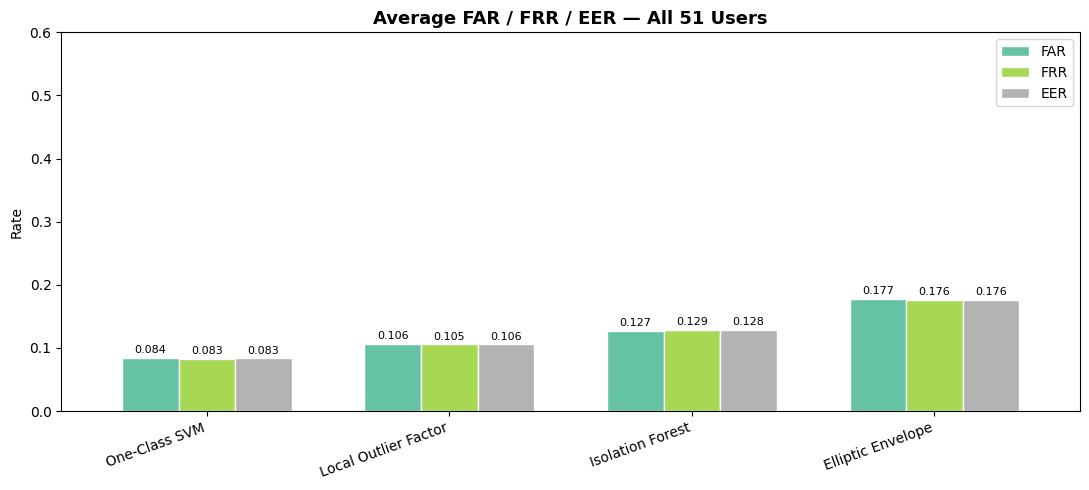

In [8]:
# ── Plot 1: Average FAR/FRR/EER per model ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
summary[["FAR", "FRR", "EER"]].plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.7)
ax.set_title("Average FAR / FRR / EER — All 51 Users", fontsize=13, fontweight="bold")
ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.set_xticklabels(summary.index, rotation=20, ha="right")
ax.legend(loc="upper right")
ax.set_ylim(0, 0.6)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

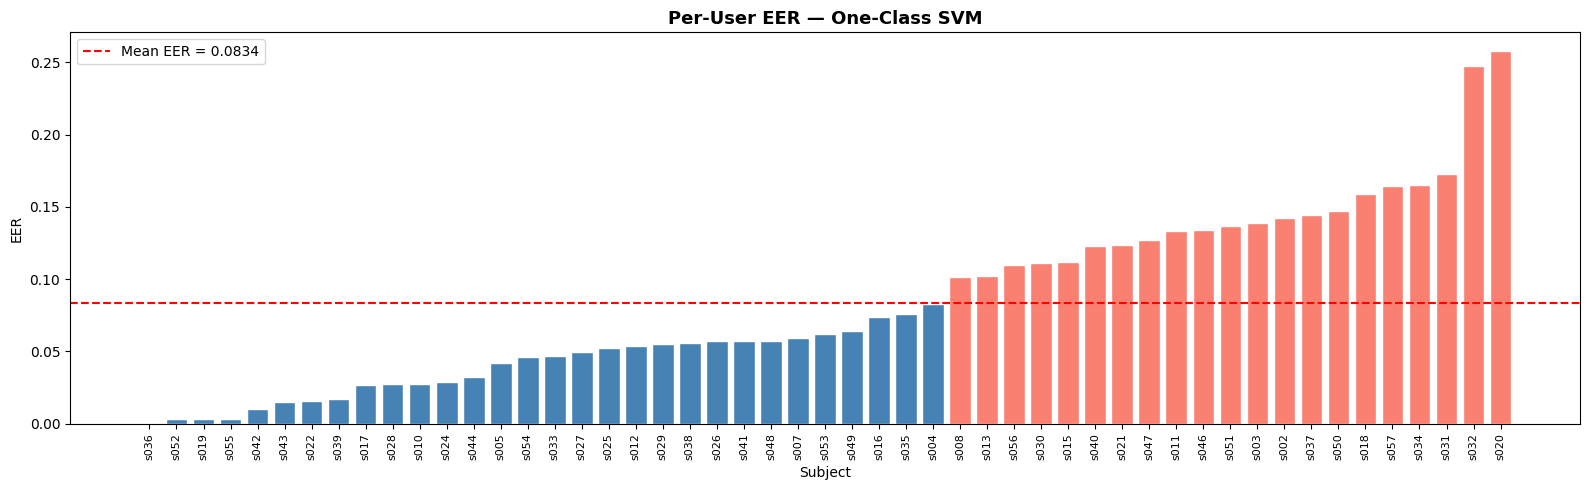

In [9]:
# ── Plot 2: Per-user EER for best model ──────────────────────
best_results = all_results_df[all_results_df["model"] == best_model].sort_values("EER")
mean_eer     = best_results["EER"].mean()

plt.figure(figsize=(16, 5))
colors = ["steelblue" if eer <= mean_eer else "salmon" for eer in best_results["EER"]]
bars   = plt.bar(best_results["subject"], best_results["EER"], color=colors, edgecolor="white")
plt.axhline(mean_eer, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean EER = {mean_eer:.4f}")
plt.title(f"Per-User EER — {best_model}", fontsize=13, fontweight="bold")
plt.xlabel("Subject")
plt.ylabel("EER")
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig("per_user_eer.png", dpi=150, bbox_inches="tight")
plt.show()

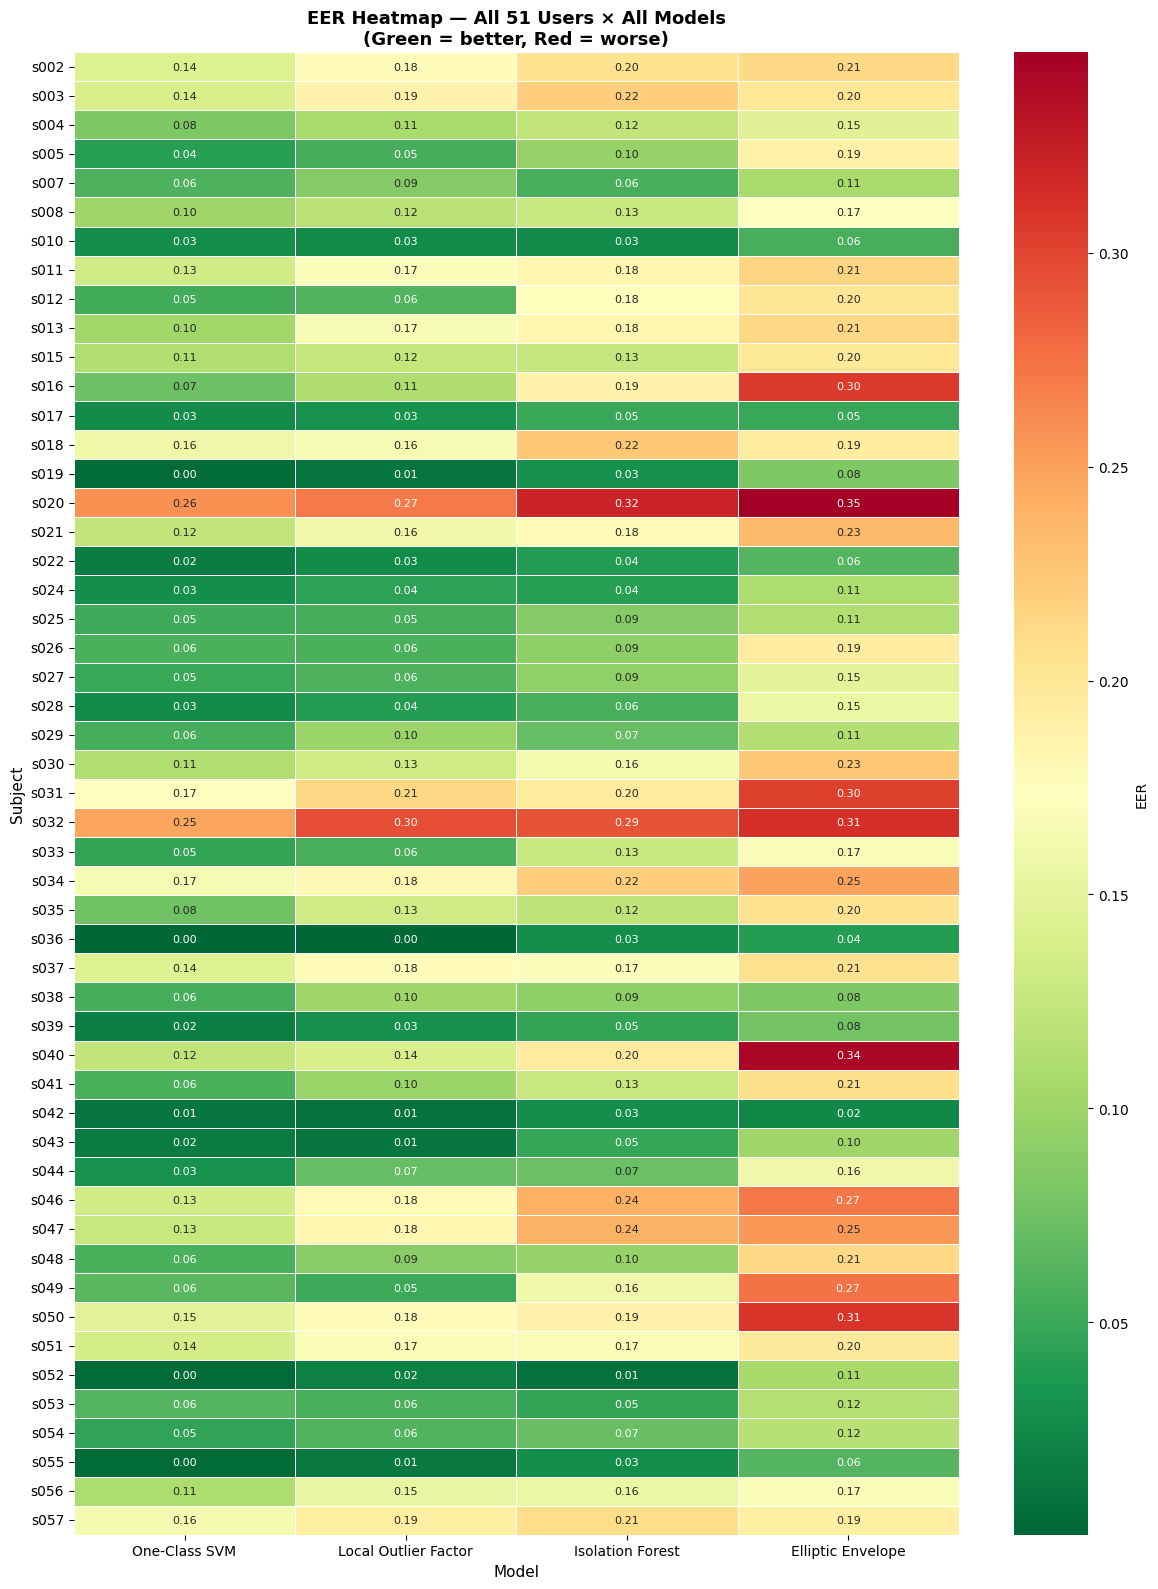

In [10]:
# ── Plot 3: EER heatmap — all users × all models ─────────────
eer_pivot = all_results_df.pivot(index="subject", columns="model", values="EER")
eer_pivot = eer_pivot[summary.index]  # sort columns by EER rank

plt.figure(figsize=(12, 16))
sns.heatmap(eer_pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
            linewidths=0.4, cbar_kws={"label": "EER"},
            annot_kws={"size": 8})
plt.title("EER Heatmap — All 51 Users × All Models\n(Green = better, Red = worse)",
          fontsize=13, fontweight="bold")
plt.xlabel("Model", fontsize=11)
plt.ylabel("Subject", fontsize=11)
plt.tight_layout()
plt.savefig("eer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

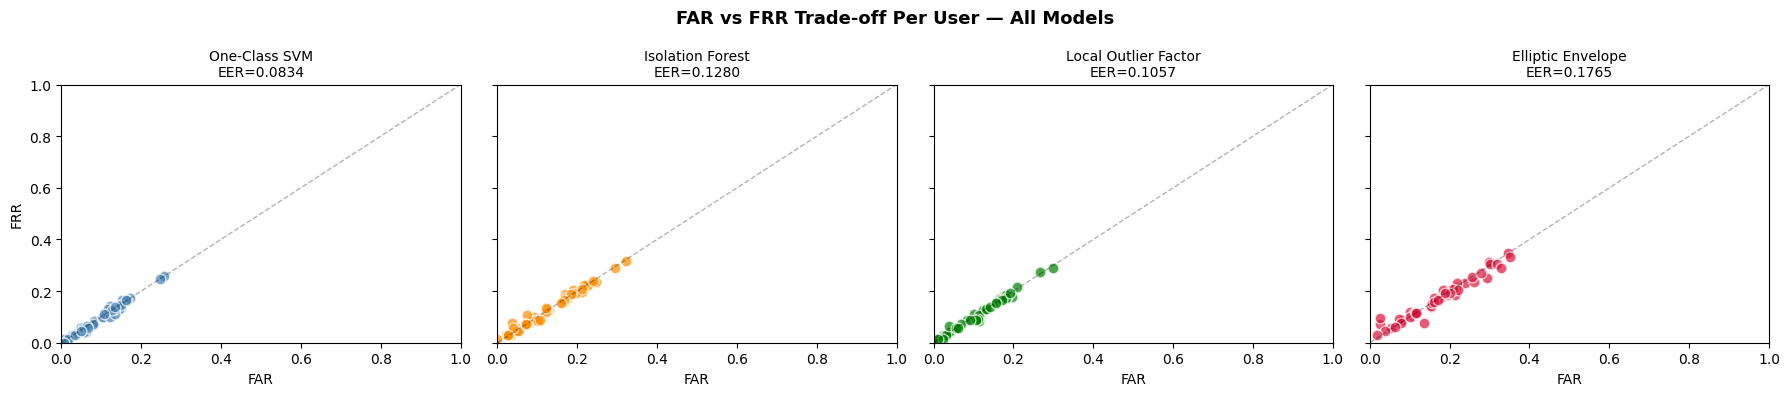


 All plots saved


In [11]:
# ── Plot 4: FAR vs FRR trade-off scatter ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("FAR vs FRR Trade-off Per User — All Models", fontsize=13, fontweight="bold")

colors_map = {
    "One-Class SVM":        "steelblue",
    "Isolation Forest":     "darkorange",
    "Local Outlier Factor": "green",
    "Elliptic Envelope":    "crimson"
}

for ax, (model_name, color) in zip(axes, colors_map.items()):
    mdf = all_results_df[all_results_df["model"] == model_name]
    ax.scatter(mdf["FAR"], mdf["FRR"], color=color, alpha=0.7, edgecolors="white", s=60)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
    ax.set_title(f"{model_name}\nEER={mdf['EER'].mean():.4f}", fontsize=10)
    ax.set_xlabel("FAR")
    if ax == axes[0]:
        ax.set_ylabel("FRR")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("far_frr_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n All plots saved")